## trainer ddp

In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import xcit_small
from trainer_ddp_07302024 import DDPTrainer, accuracy
from utils import split_train_valid, hdf5_dataset

batch_size = 180*5
num_workers = 4*5

# load data
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

imagenet_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transform)
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=batch_size,  num_workers=num_workers)
valid_dl = DataLoader(valid_ds, batch_size=batch_size,  num_workers=num_workers)

# noise
noise_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transform)
noise_dl = DataLoader(noise_ds, batch_size=batch_size, num_workers=num_workers)
    
# atom
atom_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transform)
atom_dl = DataLoader(atom_ds, batch_size=batch_size, num_workers=num_workers)


# define model and metrics
NAME = '07302024-benchmark-XCiT-v4_10m-parallel'
learning_rate = 1e-3
num_epochs = 10

device = torch.device('cuda:2')
device_ids = [2,3,6,7,8]
model = xcit_small(3, 17)
model = nn.DataParallel(model, device_ids=device_ids)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=num_epochs, max_lr=learning_rate, steps_per_epoch=len(train_dl))
metrics = [accuracy]
save_every = 1
model_path = f'../../saved_models/{NAME}/'
tracking = False

In [ ]:
trainer = DDPTrainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, device=device, 
                     save_every=save_every, model_path=model_path, rank=2, world_size=len(device_ids), use_data_parallel=True)
valid_dl_dict = {'valid': valid_dl, 'atom': atom_dl, 'noise': noise_dl}
trainer.train(train_dl, num_epochs, valid_dl_dict=valid_dl_dict, tracking=tracking)

In [1]:
%run train_ddp3.py

In [4]:
%run train_ddp2.py

In [ ]:
import os
import torch
import torch.nn as nn
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.utils.data import DataLoader
from torchvision import transforms

# Import your custom modules
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import xcit_small
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset

def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'
    os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, GPU_IDS))
    dist.init_process_group("nccl", rank=rank, world_size=world_size)

def cleanup():
    dist.destroy_process_group()

def train_model(rank, world_size):
    setup(rank, world_size)
    
    device = torch.device(f"cuda:{rank}")
    
    model = xcit_small(3, 17).to(device)
    model = DDP(model, device_ids=[rank])
    
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transform)
    train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
    
    train_sampler = DistributedSampler(train_ds, num_replicas=world_size, rank=rank)
    valid_sampler = DistributedSampler(valid_ds, num_replicas=world_size, rank=rank)
    
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS)
    valid_dl = DataLoader(valid_ds, batch_size=BATCH_SIZE, sampler=valid_sampler, num_workers=NUM_WORKERS)
    
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=NUM_EPOCHS, max_lr=LEARNING_RATE, steps_per_epoch=len(train_dl))
    
    for epoch in range(START_EPOCH, NUM_EPOCHS):
        model.train()
        train_sampler.set_epoch(epoch)
        train_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_dl):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = loss_func(output, target)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            
            if batch_idx % 100 == 0 and rank == 0:
                print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Batch {batch_idx}/{len(train_dl)}, Loss: {loss.item():.4f}')
        
        model.eval()
        valid_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in valid_dl:
                data, target = data.to(device), target.to(device)
                output = model(data)
                valid_loss += loss_func(output, target).item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()
        
        if rank == 0:
            print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss/len(train_dl):.4f}, '
                  f'Valid Loss: {valid_loss/len(valid_dl):.4f}, '
                  f'Valid Accuracy: {100.*correct/total:.2f}%')
    
    cleanup()

def run_training():
    mp.spawn(train_model, args=(WORLD_SIZE,), nprocs=WORLD_SIZE, join=True)


# Global variables
GPU_IDS = [7, 8]
WORLD_SIZE = len(GPU_IDS)
NUM_WORKERS = 8  # Adjust as needed
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
START_EPOCH = 0
NUM_EPOCHS = 20

# analyze

In [ ]:
from analysis_functions import confusion_matrix, plot_cm

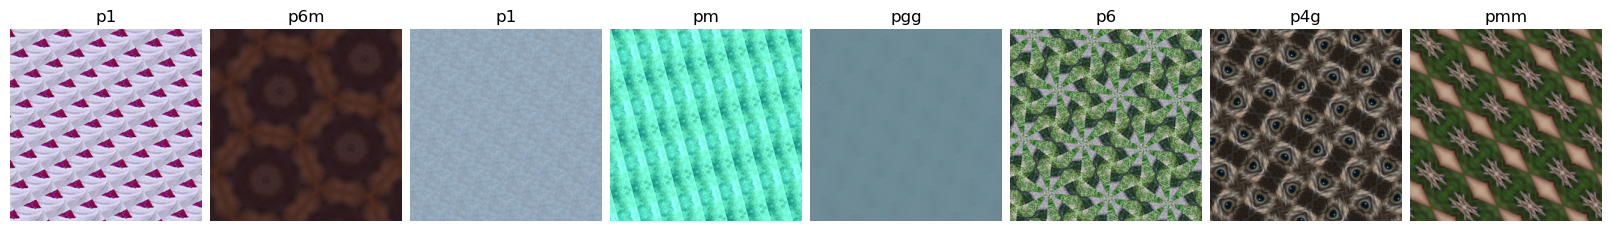

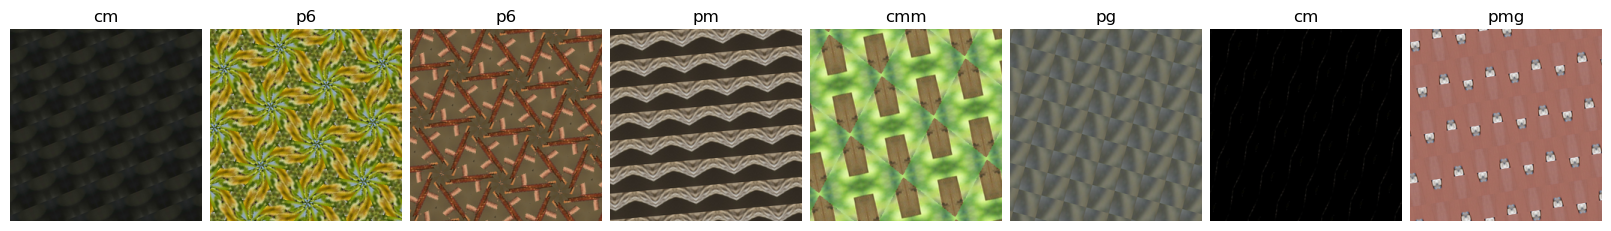

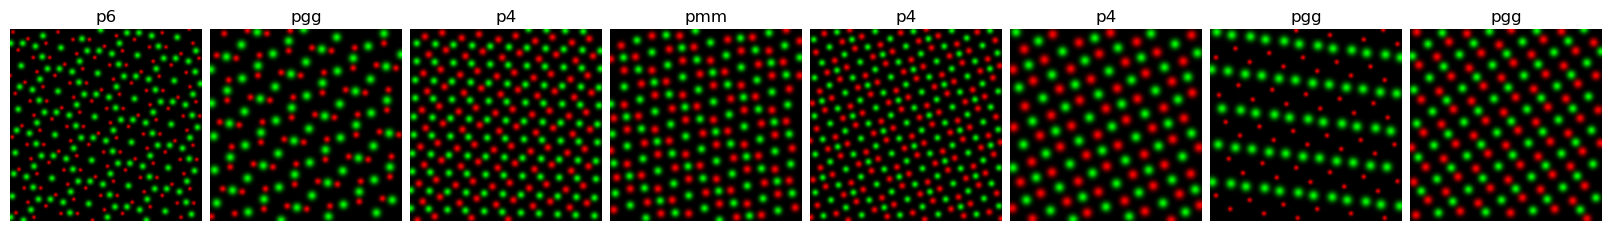

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../../imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('../../../../imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter)

# atom
test_ds = hdf5_dataset('../../../../atom_v4_rot_2m_unchunked_fixed.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter)

In [ ]:
device = torch.device('cuda:0')
model = torch.load('../../../saved_models/01102024-benchmark-XCiT-v4_10m/01102024-benchmark-XCiT-v4_10m-epoch-20.pt').module
model = model.to(device)

NAME = '01102024-benchmark-XCiT-v4_10m'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [ ]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 156252/156252 [14:30:41<00:00,  2.99it/s]  

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.999640802873577



ImageNet Symmetry Dataset


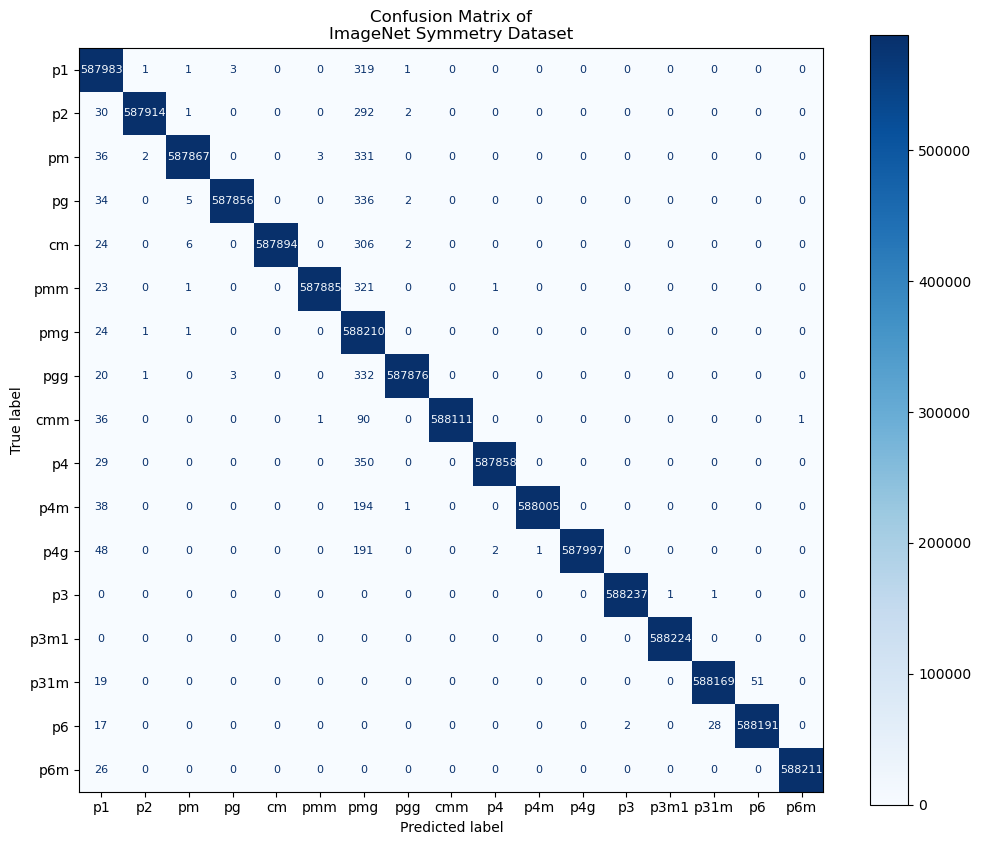

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, file_path=f'{NAME}-train_cm', title='\nImageNet Symmetry Dataset', style='simple', font_size=8)
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

  0%|          | 0/31251 [00:00<?, ?it/s]

100%|██████████| 31251/31251 [2:54:10<00:00,  2.99it/s]  

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.999438004495964



ImageNet Symmetry Dataset


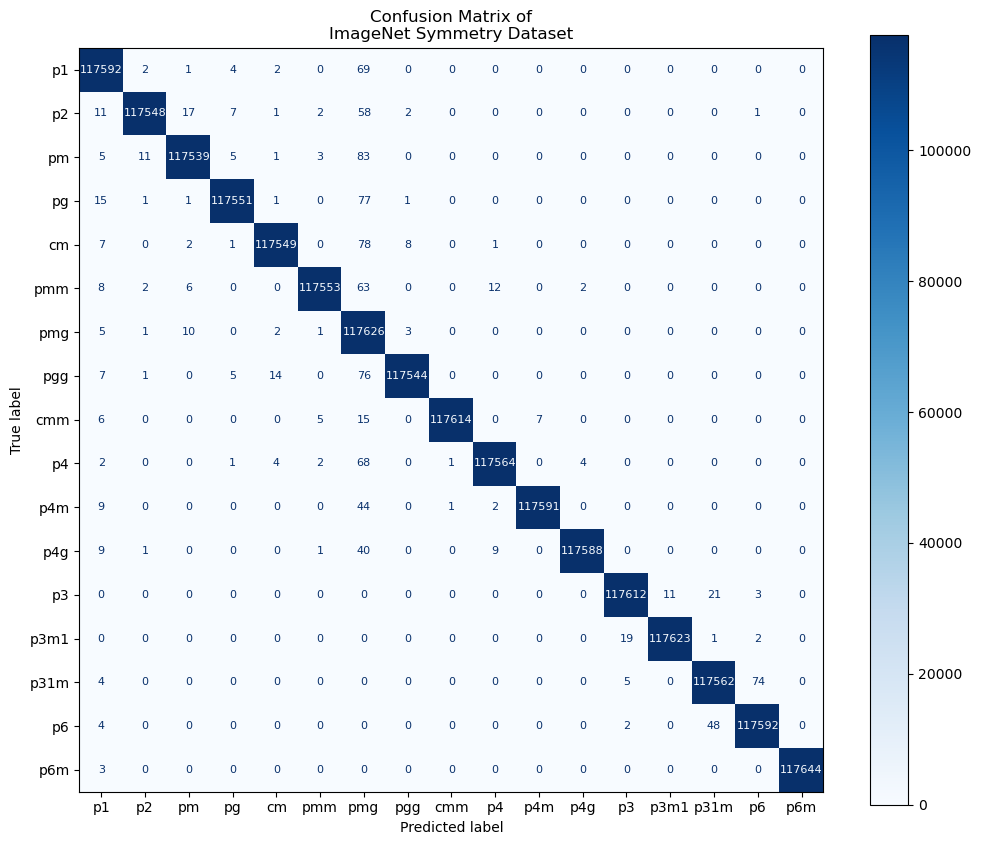

In [ ]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, file_path=f'{NAME}-valid_cm', title='\nImageNet Symmetry Dataset', style='simple', font_size=8)
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

  0%|          | 0/29257 [00:00<?, ?it/s]

100%|██████████| 29257/29257 [2:42:30<00:00,  3.00it/s]  

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5242868762587246



Atom Symmetry Dataset


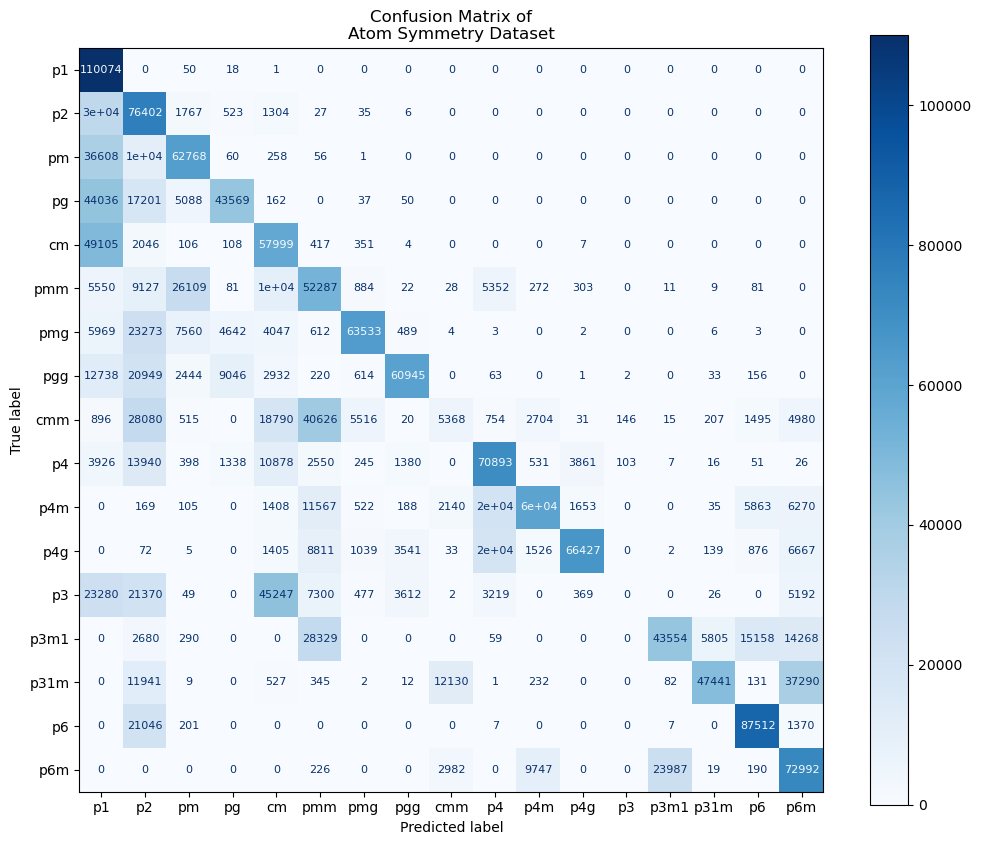

In [ ]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, file_path=f'{NAME}-test_cm', title='\nAtom Symmetry Dataset', style='simple', font_size=8)
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset

import sys
sys.path.append('../../src/')
from build_model import resnet50
from dataset_functions import hdf5_dataset, list_to_dict, viz_dataloader

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

model = resnet50(3, 17)

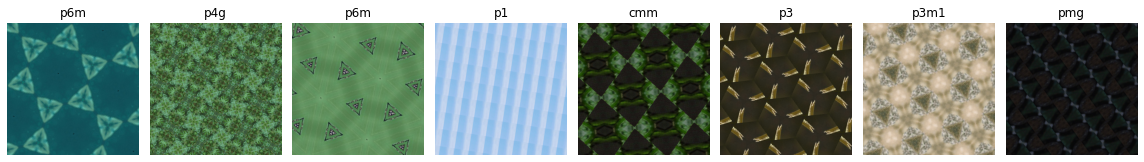

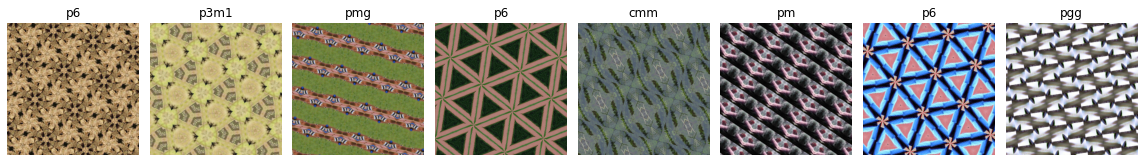

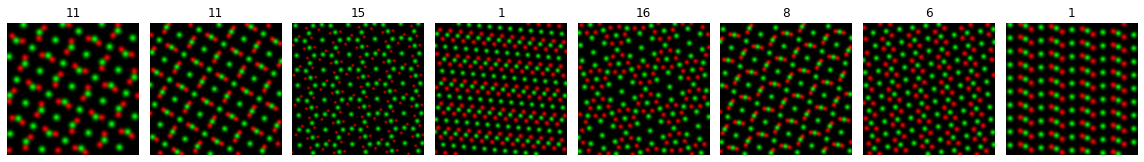

CPU times: user 28.9 s, sys: 1.07 s, total: 29.9 s
Wall time: 9.03 s


In [ ]:
%%time
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=230, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter)

# train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
# train_dl = DataLoader(train_ds, batch_size=230, shuffle=True, num_workers=2)
# viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=230, shuffle=True, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=1024, shuffle=True, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter)

# analyze

In [ ]:
model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

In [ ]:
sys.path.append('../src/')
from confusion_matrix_functions import confusion_matrix, plot_cm
NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

In [ ]:
device = torch.device('cuda:2')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 43479/43479 [2:17:30<00:00,  5.27it/s]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996354029167767


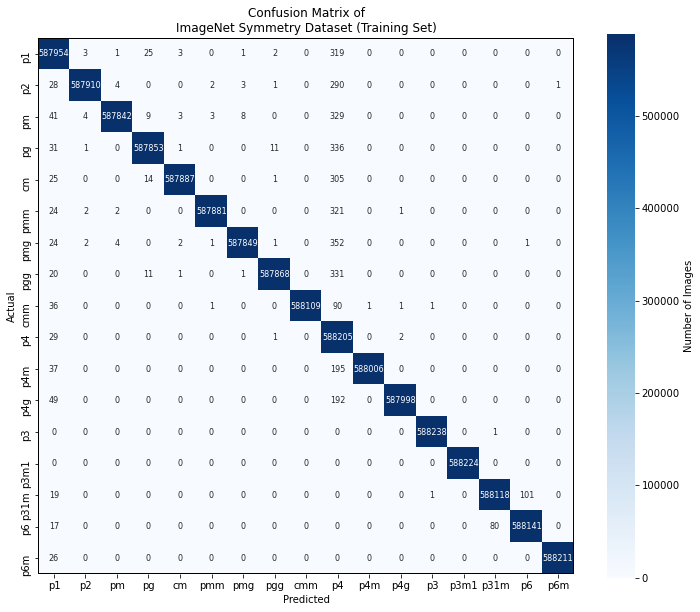

In [ ]:
cm = np.load(NAME+'-train_cm.npy')

plot_cm(cm, symmetry_classes, save_file=NAME+'-train_cm.svg', title='\nImageNet Symmetry Dataset (Training Set)', style='with_axis')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


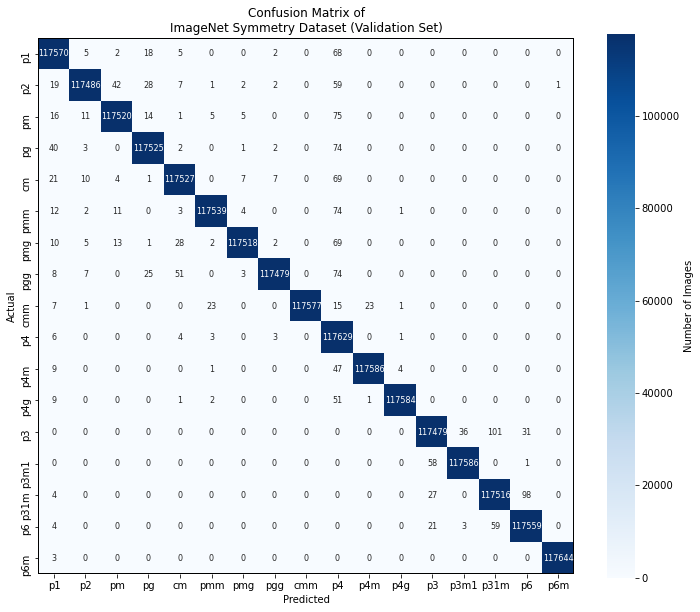

In [ ]:
cm = np.load(NAME+'-valid_cm.npy')

plot_cm(cm, symmetry_classes, save_file=NAME+'-valid_cm.svg', title='\nImageNet Symmetry Dataset (Validation Set)', style='with_axis')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


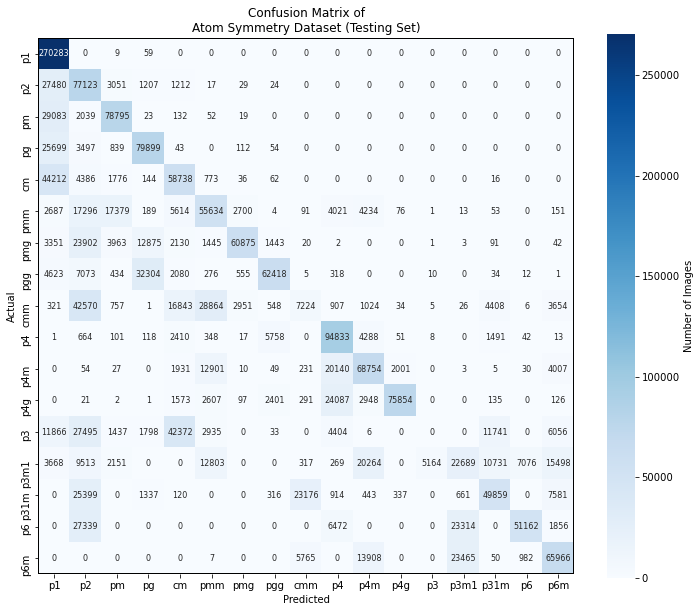

In [ ]:
cm = np.load(NAME+'-test_cm.npy')

plot_cm(cm, symmetry_classes, save_file=NAME+'-test_cm.svg', title='\nAtom Symmetry Dataset (Testing Set)', style='with_axis')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')